In [135]:
import pandas as pd
from sklearn.model_selection import train_test_split 
import torch 
from torch.utils.data import Dataset, DataLoader 
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt 

In [136]:
torch.manual_seed(42)

In [137]:
# Check for GPU 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device
torch.cuda.is_available()
print(torch.__path__)

['d:\\Code\\Python\\ann-classification\\venv\\Lib\\site-packages\\torch']


In [138]:
df = pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


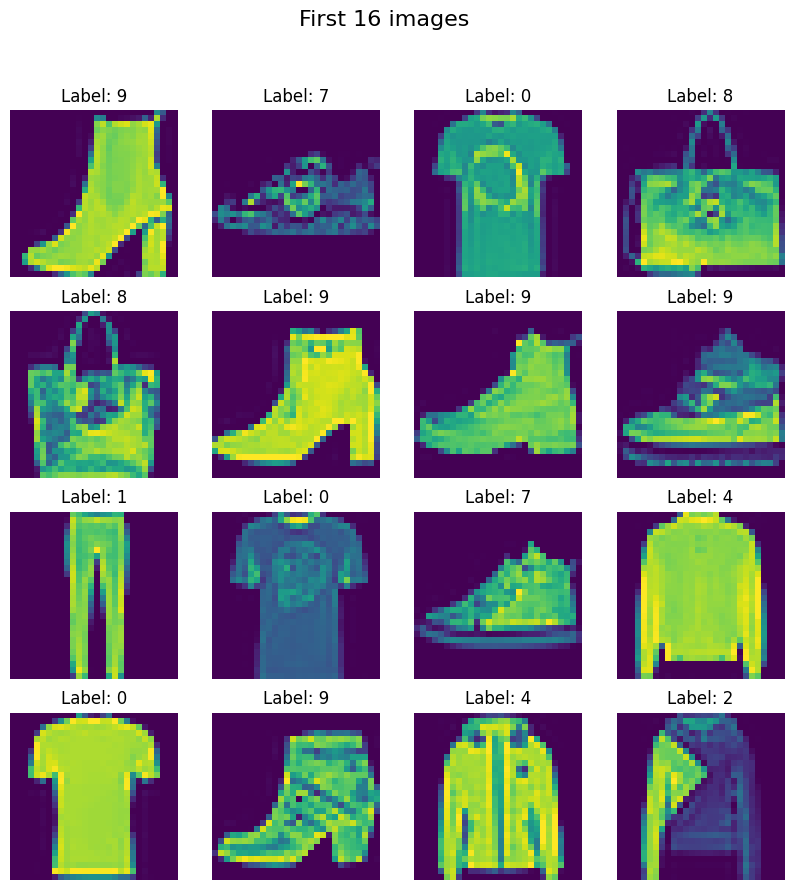

In [139]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.show()

In [140]:
# train test split 
X = df.iloc[:, 1:].values 
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [141]:
# Scaling the features (as most values are between 0 to 255)
X_train = X_train / 255.0
X_test = X_test / 255.0

In [157]:
class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):
        super().__init__()

        layers = []
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [158]:
class CustomDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long) 

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [159]:
# Create train and test data sets
train_dataset = CustomDataSet(X_train, y_train)
test_dataset = CustomDataSet(X_test, y_test)

In [160]:
# Objective function 
def objective(trial):
    # Next hyperparameter value from search space 
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layers = trial.suggest_int('neurons_per_layers', 8, 128, step=8)
    epochs = trial.suggest_int('epochs', 10, 50, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD', 'RMSProp'])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    # Create train and test data loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Model init 
    input_dim = 784 
    output_dim = 10
    
    model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layers, dropout_rate)

    # Param init 
    # learning_rate = 0.01 
    # epochs = 50

    # Optimizer selection 
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else: 
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Training loop 
    for epoch in range(epochs):
        total_epoch_loss = 0
        for batch_features, batch_labels in train_loader:
            # forward pass 
            output = model(batch_features)
            # calculate loss 
            loss = criterion(output, batch_labels)
            # backward pass 
            optimizer.zero_grad()
            loss.backward()
            # update grad
            optimizer.step()

            total_epoch_loss += loss.item()

        avg_loss = total_epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Loss: {avg_loss}")

    # Evaluation 
    model.eval()
    # Evaluation on test data
    total = 0
    correct = 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total = total + batch_labels.shape[0]
            correct = correct + (predicted == batch_labels).sum().item()

    print("Test Accuracy = ", correct/total)

    return correct/total

In [161]:
import optuna 

study = optuna.create_study(direction='maximize')

[I 2025-07-31 13:39:35,205] A new study created in memory with name: no-name-dd7a0baa-7fbf-4acf-957f-1ed91f48b2f5


In [162]:
study.optimize(objective, n_trials=10)

d:\Code\Python\ann-classification\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1 - Loss: 2.4032161898083158
Epoch 2 - Loss: 2.335410475730896
Epoch 3 - Loss: 2.3114637533823648
Epoch 4 - Loss: 2.2667545610004
Epoch 5 - Loss: 2.2441375851631165
Epoch 6 - Loss: 2.209260755115085
Epoch 7 - Loss: 2.1802770561642117
Epoch 8 - Loss: 2.1612708833482532
Epoch 9 - Loss: 2.119992176691691
Epoch 10 - Loss: 2.0850832098060184
Epoch 11 - Loss: 2.0645733376344046
Epoch 12 - Loss: 2.0384435885482364
Epoch 13 - Loss: 1.9981930885050032
Epoch 14 - Loss: 1.9605341752370198
Epoch 15 - Loss: 1.9293146067195468
Epoch 16 - Loss: 1.9157949321799808
Epoch 17 - Loss: 1.8716850479443867
Epoch 18 - Loss: 1.83807991610633
Epoch 19 - Loss: 1.8285699519846175
Epoch 20 - Loss: 1.7930823730097876
Epoch 21 - Loss: 1.7679559687773387
Epoch 22 - Loss: 1.7315908306174808
Epoch 23 - Loss: 1.7185301515791152
Epoch 24 - Loss: 1.669501976834403
Epoch 25 - Loss: 1.6500881214936574
Epoch 26 - Loss: 1.6235802272955577
Epoch 27 - Loss: 1.6041803028848436
Epoch 28 - Loss: 1.5702044301562839
Epoch 29 -

[I 2025-07-31 13:39:45,528] Trial 0 finished with value: 0.6873333333333334 and parameters: {'num_hidden_layers': 4, 'neurons_per_layers': 40, 'epochs': 40, 'learning_rate': 0.00018394161079565472, 'dropout_rate': 0.5, 'batch_size': 128, 'optimizer_name': 'Adam', 'weight_decay': 8.814829773120838e-05}. Best is trial 0 with value: 0.6873333333333334.


Epoch 40 - Loss: 1.371688014931149
Test Accuracy =  0.6873333333333334
Epoch 1 - Loss: 1.8701752365058195
Epoch 2 - Loss: 1.631262187416672
Epoch 3 - Loss: 1.5012742204869047
Epoch 4 - Loss: 1.3966967290174876
Epoch 5 - Loss: 1.3153377534649897
Epoch 6 - Loss: 1.2463063242587638
Epoch 7 - Loss: 1.195144866797941
Epoch 8 - Loss: 1.1646841333267537


[I 2025-07-31 13:39:47,190] Trial 1 finished with value: 0.768 and parameters: {'num_hidden_layers': 1, 'neurons_per_layers': 16, 'epochs': 10, 'learning_rate': 0.0003050302677938801, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer_name': 'Adam', 'weight_decay': 2.9610436035427182e-05}. Best is trial 1 with value: 0.768.


...

Epoch 50 - Loss: 0.09316729205764002
Test Accuracy =  0.834
Epoch 1 - Loss: 2.2774165272712708
Epoch 2 - Loss: 2.1809374160236783
Epoch 3 - Loss: 2.119590779145559
Epoch 4 - Loss: 2.0674950877825418
Epoch 5 - Loss: 2.035397059387631
Epoch 6 - Loss: 2.011138869656457
Epoch 7 - Loss: 1.9885393977165222
Epoch 8 - Loss: 1.9364195234245725


[I 2025-07-31 13:41:57,169] Trial 8 finished with value: 0.37 and parameters: {'num_hidden_layers': 5, 'neurons_per_layers': 8, 'epochs': 10, 'learning_rate': 0.001341826120538248, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer_name': 'RMSProp', 'weight_decay': 1.641625459014615e-05}. Best is trial 7 with value: 0.834.


Epoch 9 - Loss: 1.9265252782238855
Epoch 10 - Loss: 1.8910282287332747
Test Accuracy =  0.37
Epoch 1 - Loss: 2.3776080891595663
Epoch 2 - Loss: 2.2691804635609296
Epoch 3 - Loss: 2.2002480524651546
Epoch 4 - Loss: 2.1171544443631003
Epoch 5 - Loss: 2.0373932503639383
Epoch 6 - Loss: 1.9569254766964743
Epoch 7 - Loss: 1.8759652164810938
Epoch 8 - Loss: 1.8018400914280126
Epoch 9 - Loss: 1.746160461124799


[I 2025-07-31 13:42:13,466] Trial 9 finished with value: 0.558 and parameters: {'num_hidden_layers': 5, 'neurons_per_layers': 64, 'epochs': 10, 'learning_rate': 6.813247625506948e-05, 'dropout_rate': 0.4, 'batch_size': 16, 'optimizer_name': 'Adam', 'weight_decay': 0.0004703297329879308}. Best is trial 7 with value: 0.834.


Epoch 10 - Loss: 1.6757890899130639
Test Accuracy =  0.558


In [163]:
print(study.best_params)
print(study.best_value)

{'num_hidden_layers': 2, 'neurons_per_layers': 72, 'epochs': 50, 'learning_rate': 0.0011892347904362511, 'dropout_rate': 0.2, 'batch_size': 128, 'optimizer_name': 'Adam', 'weight_decay': 8.80674830113412e-05}
0.834


In [ ]:
class MyNN_custom(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [124]:
epochs = 100
learning_rate = 0.1

In [ ]:
# # Instantiate the model
# model = MyNN(X_train.shape[1])

# # Loss function 
# criterion = nn.CrossEntropyLoss()

# # optimizer b
# optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [126]:
len(train_loader)

141

In [ ]:
# for epoch in range(epochs):
#     total_epoch_loss = 0
#     for batch_features, batch_labels in train_loader:
#         # forward pass 
#         output = model(batch_features)
#         # calculate loss 
#         loss = criterion(output, batch_labels)
#         # backward pass 
#         optimizer.zero_grad()
#         loss.backward()
#         # update grad
#         optimizer.step()

#         total_epoch_loss += loss.item()

#     avg_loss = total_epoch_loss / len(train_loader)
#     print(f"Epoch {epoch+1} - Loss: {avg_loss}")

Epoch 1 - Loss: 0.9715504806937901
Epoch 2 - Loss: 0.6816717198131778
Epoch 3 - Loss: 0.6398321683947922
Epoch 4 - Loss: 0.5675594569943475
Epoch 5 - Loss: 0.5142413558478051
Epoch 6 - Loss: 0.5043099442272322
Epoch 7 - Loss: 0.4893885116416512
Epoch 8 - Loss: 0.45612093172174817
Epoch 9 - Loss: 0.44978321454626446
Epoch 10 - Loss: 0.41629848549974724
Epoch 11 - Loss: 0.4107616611406313
Epoch 12 - Loss: 0.4052943486905267
Epoch 13 - Loss: 0.3797599641566581
Epoch 14 - Loss: 0.3726303412559185
Epoch 15 - Loss: 0.3474495987414468
Epoch 16 - Loss: 0.3348076736144986
Epoch 17 - Loss: 0.3585458992854923
Epoch 18 - Loss: 0.335322194224131
Epoch 19 - Loss: 0.3381466739249568
Epoch 20 - Loss: 0.3222264977211648
Epoch 21 - Loss: 0.31843266049598123
Epoch 22 - Loss: 0.308520607967326
Epoch 23 - Loss: 0.27661349708940963
Epoch 24 - Loss: 0.2854174233391775
Epoch 25 - Loss: 0.2779627905775469
Epoch 26 - Loss: 0.2682404401348838
Epoch 27 - Loss: 0.27574434345389937
Epoch 28 - Loss: 0.25673589340232

In [ ]:
# Set model to eval mode 
# model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# # Evaluation on test data
# total = 0
# correct = 0
# with torch.no_grad():
#   for batch_features, batch_labels in test_loader:
#     outputs = model(batch_features)
#     _, predicted = torch.max(outputs, 1)
#     total = total + batch_labels.shape[0]
#     correct = correct + (predicted == batch_labels).sum().item()

# print("Test Accuracy = ", correct/total)

Test Accuracy =  0.7893333333333333


In [ ]:
# # Evaluation on training data
# total = 0
# correct = 0
# with torch.no_grad():
#   for batch_features, batch_labels in train_loader:
#     outputs = model(batch_features)
#     _, predicted = torch.max(outputs, 1)
#     total = total + batch_labels.shape[0]
#     correct = correct + (predicted == batch_labels).sum().item()

# print("Training Accuracy = ", correct/total)

Training Accuracy =  0.9144444444444444
